## Problem Statement 
given two tabular datasets containing lab-measured properties of wines. goal 
is to build a multi-class classification model that predicts the wine’s quality score and then 
conduct a comparative study: 
1.  Red vs White dataset: Which dataset is easier to predict and why? 
2.  Model vs Model: Which model performs better on each dataset and why? 
3.  Class-level difficulty: Which quality scores are hardest to predict? 


### Data Description  

What one row represents :Each row is one wine sample with measured chemical/physical properties. 

Target column 

●  quality: an integer quality rating assigned to the wine. 

●  For this assignment, treat each unique value of quality as a separate class 
(multi-class classification). 
 
        
These are common wine chemistry measurements: 

●  fixed acidity: stable acids in wine 

●  volatile acidity: acetic acid (high values can reduce quality) 

●  citric acid: adds freshness 

●  residual sugar: sugar left after fermentation 

●  chlorides: salt content 

●  free sulfur dioxide / total sulfur dioxide: preservatives (SO₂ levels) 

●  density: related to alcohol and sugar 

●  pH: acidity level 

●  sulphates: stability/preservation 

●  alcohol: alcohol percentage

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)
import warnings
warnings.filterwarnings('ignore')

### Task 1 — Load & Inspect the Data (Red + White)

In [2]:
red_df=pd.read_csv(r'D:\D\adsw\DSA\hvc\ML_graded_assignment\winequality-red.csv',sep=';')
white_df=pd.read_csv(r'D:\D\adsw\DSA\hvc\ML_graded_assignment\winequality-white.csv',sep=';')

In [3]:
red_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
white_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
red_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
white_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


data types are correct

In [9]:
red_df.shape

(1599, 12)

In [10]:
white_df.shape

(4898, 12)

In [11]:
'quality' in red_df.columns

True

'quality' feature does exist in red_df

In [12]:
'quality' in white_df

True

'quality' feature does exist in white_df

### Task 2 — Data Quality Checks + Class Distribution (Comparative)

In [7]:
red_df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
white_df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

No Null Values

In [13]:
red_df.duplicated().sum()

np.int64(240)

In [14]:
red_df[red_df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [15]:
white_df.duplicated().sum()

np.int64(937)

In [16]:
white_df[white_df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.900000,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.100000,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.800000,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.500000,6
20,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.98920,3.33,0.39,12.800000,8
...,...,...,...,...,...,...,...,...,...,...,...,...
4828,6.4,0.23,0.35,10.3,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
4850,7.0,0.36,0.35,2.5,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
4851,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
4856,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


240 duplicate datapoints in red_df and 937 dupliacte datapoints in white_df

In [17]:
red_df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [18]:
white_df['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [19]:
red_quality_proprotion=red_df['quality'].value_counts(normalize=True).sort_index()*100
red_quality_proprotion

quality
3     0.625391
4     3.314572
5    42.589118
6    39.899937
7    12.445278
8     1.125704
Name: proportion, dtype: float64

In [20]:
white_quality_proportion=white_df['quality'].value_counts(normalize=True).sort_index()*100
white_quality_proportion

quality
3     0.408330
4     3.327889
5    29.746835
6    44.875459
7    17.966517
8     3.572887
9     0.102082
Name: proportion, dtype: float64

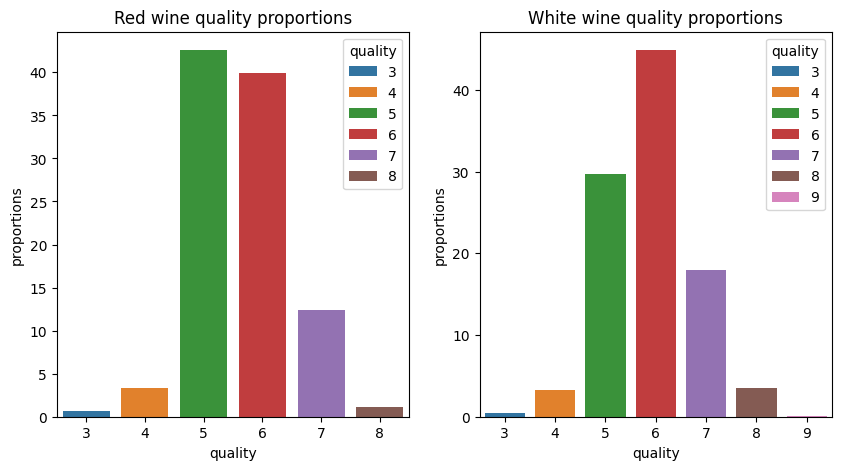

In [21]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(x=red_quality_proprotion.index,y=red_quality_proprotion.values,hue=red_quality_proprotion.index,palette='tab10')
plt.title('Red wine quality proportions')
plt.xlabel('quality')
plt.ylabel('proportions')


plt.subplot(1,2,2)
sns.barplot(x=white_quality_proportion.index,y=white_quality_proportion.values,hue=white_quality_proportion.index,palette='tab10')
plt.title('White wine quality proportions')
plt.xlabel('quality')
plt.ylabel('proportions')

plt.show()

-  Which dataset is more imbalanced?
    - in red wine:
        - quality 5 and 6 dominate the dataset contibuting 82% of the red wine dataset
        - quality 7 is very little prominant contributing around 12% 
        - quality 3,4 and 8 are severly underrepresented contibuting less than 5% of the dataset
    - in white wine:
        - quality 6 is most dominant contributing 45% of the total white dataset followed by quality 5 contributing around 30%
        - quality 7 is little more prominant in white than red contributing around 18%
        - quality 3,4,8 and 9 make up just around 7.3% of total white wine dataset
    - hence 
        - from the perspective of dominance of classes then white wine is more imbalaced as quality 6 dominates the entire dataset with contribution of 45% while in red wine quality 5 and 6 dominates with 42% and 39% hence white wine is more imbalanced
        - from the perspective of spread of data across different classes,in red wine top qualities 5 and 6 makes up 82% leaving just 18 percent of the entire dataset for other 4 class while in white wine qualities 5 and 6 makes up 75% and leaves 25% of the entire dataset and gives chance to datapoints to spread across other classes hence red wine is more imbalaced


-  Which quality classes are rare?
    - 'the most rare quality classes across both datasets are the extreme ends of the spectrum: 3, 4, 8, and 9.
        - specifically:
            - in red wine: qualities 3 and 8 are the rarest ,around 1% each. quality 4 is also quite rare about 3%.
            - in white wine: quality 9 is the absolute rarest ,almost 0%. qualities 3, 4, and 8 are also very rare ,sum of all is under 5%.


-  Why might rare classes be harder to predict?
    - MODEL BIAS: if we train a model on this raw datsets,model will be heavily biased towards quality 5 aand 6 
    - POOR MINORITY RECOGNITION : model's performance will be very low in preedicting minority classes as it has not seen enough examples of minority classes and underlying chemical patterns
    - MISLEADING ACCURACY : a standard accuracy will be high as there is huge variance between counts of the  dominant classes as compared to minority classes,we need to look at recall,f1-macro and confusion matrix see the performance of model in predicting minority classes 


### Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)

In [22]:
red_x=red_df.drop(columns=['quality'])
red_y=red_df['quality']
white_x=white_df.drop(columns=['quality'])
white_y=white_df['quality']

global_random_state=42
from sklearn.model_selection import train_test_split
rx_train,rx_test,ry_train,ry_test=train_test_split(red_x,red_y,test_size=0.2,random_state=global_random_state,stratify=red_y)
wx_train,wx_test,wy_train,wy_test=train_test_split(white_x,white_y,test_size=0.2,random_state=global_random_state,stratify=white_y)

print(f"rx_train shape : {rx_train.shape}")
print(f"rx_test shape : {rx_test.shape}")
print(f"ry_train shape : {ry_train.shape}")
print(f"ry_test shape : {ry_test.shape}")

print(f"wx_train shape : {wx_train.shape}")
print(f"wx_test shape : {wx_test.shape}")
print(f"wy_train shape : {wy_train.shape}")
print(f"wy_test shape : {wy_test.shape}")

print(f"Class distribution in red_y :\n {red_y.value_counts(normalize=True)}")
print(f"Class distribution in ry_train :\n {ry_train.value_counts(normalize=True)}")
print(f"Class distribution in ry_test :\n {ry_test.value_counts(normalize=True)}")

print(f"Class distribution in white_y :\n {white_y.value_counts(normalize=True)}")
print(f"Class distribution in wy_train :\n {wy_train.value_counts(normalize=True)}")
print(f"Class distribution in wy_test :\n {wy_test.value_counts(normalize=True)}")

rx_train shape : (1279, 11)
rx_test shape : (320, 11)
ry_train shape : (1279,)
ry_test shape : (320,)
wx_train shape : (3918, 11)
wx_test shape : (980, 11)
wy_train shape : (3918,)
wy_test shape : (980,)
Class distribution in red_y :
 quality
5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: proportion, dtype: float64
Class distribution in ry_train :
 quality
5    0.426114
6    0.398749
7    0.124316
4    0.032838
8    0.011728
3    0.006255
Name: proportion, dtype: float64
Class distribution in ry_test :
 quality
5    0.425000
6    0.400000
7    0.125000
4    0.034375
8    0.009375
3    0.006250
Name: proportion, dtype: float64
Class distribution in white_y :
 quality
6    0.448755
5    0.297468
7    0.179665
8    0.035729
4    0.033279
3    0.004083
9    0.001021
Name: proportion, dtype: float64
Class distribution in wy_train :
 quality
6    0.448698
5    0.297601
7    0.179684
8    0.035733
4    0.033180
3    0.004084
9    0.001021
Name: propo

### Task 4 — Model A (Baseline): Logistic Regression (Red vs White) 

F1_macro Score red : 0.27762808067026984
F1_macro Score white : 0.2366945241169341
Accuracy Score red : 0.590625
Accuracy Score white : 0.5489795918367347
classification report  red : 
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320

classification report white : 
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.5

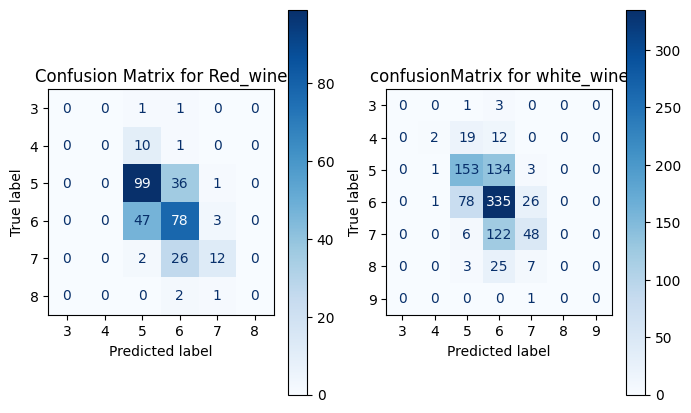

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,classification_report



log_reg_pipe=Pipeline(
    steps=[
        ('preprocessing',StandardScaler()),
        ('log_model',LogisticRegression(max_iter=5000))
    ]
)

log_reg_pipe.fit(rx_train,ry_train)
ry_pred_log=log_reg_pipe.predict(rx_test)
cm_red=confusion_matrix(ry_test,ry_pred_log)


log_reg_pipe.fit(wx_train,wy_train)
wy_pred_log=log_reg_pipe.predict(wx_test)
cm_white=confusion_matrix(wy_test,wy_pred_log)

print(f"F1_macro Score red : {f1_score(ry_test,ry_pred_log,average='macro')}")
print(f"F1_macro Score white : {f1_score(wy_test,wy_pred_log,average='macro')}")
print(f"Accuracy Score red : {accuracy_score(ry_test,ry_pred_log)}")
print(f"Accuracy Score white : {accuracy_score(wy_test,wy_pred_log)}")
print(f"classification report  red : \n {classification_report(ry_test,ry_pred_log)}")
print(f"classification report white : \n {classification_report(wy_test,wy_pred_log)}")


fig,axes=plt.subplots(1,2,figsize=(8,5))
disp_red=ConfusionMatrixDisplay(confusion_matrix=cm_red,display_labels=np.unique(ry_train))
disp_red.plot(cmap=plt.cm.Blues,ax=axes[0])
axes[0].set_title('Confusion Matrix for Red_wine')

disp_white=ConfusionMatrixDisplay(confusion_matrix=cm_white,display_labels=np.unique(wy_train))
disp_white.plot(cmap=plt.cm.Blues,ax=axes[1])
axes[1].set_title('confusionMatrix for white_wine')
plt.show()

- Which dataset performed better for Logistic Regression?
    - the red whine performed slightly better
        - Accuracy : Red wine(0.59)>white wine(0.55)
        - f1_macro : Red wine(0.28)>white wine(0.24)
            - while both the models struggling in the overall performance,logistic regression model is better in classifying red wines than white wines
-  Which quality class looks hardest (lowest recall)?
    - the model is failing almost completely on the extreme minority classes in both datasets (the lowest and highest quality wines).
     - specifically:
        - for red wine: classes 3, 4, and 8 are the hardest. the model has a recall of 0.00 for all of them, meaning out of all the true instances of those classes in the test set, the model successfully identified exactly 0.
        - for white wine: classes 3, 8, and 9 have a recall of 0.00. class 4 is also extremely poor with a recall of just 0.06 (it only found 2 out of 33 instances).
        
because these extreme quality classes have very few samples in the training data , the logistic regression model is heavily biased toward simply predicting the most common, average-quality classes (5 and 6) to minimize its overall error, severely hurting the recall on the rare classes.

### Task 5 — Model B (Tree Model): Random Forest (Red vs White)

F1_macro Score red : 0.40942034451633624
F1_macro Score white : 0.42216712111154814
Accuracy Score red : 0.68125
Accuracy Score white : 0.6724489795918367
classification report  red : 
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320

classification report white : 
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.6

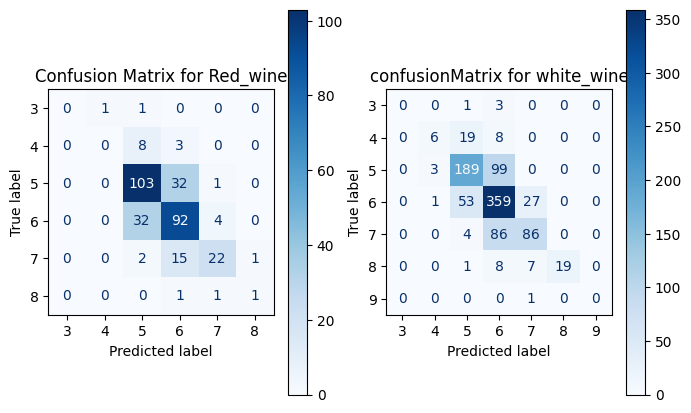

In [24]:
from sklearn.ensemble import RandomForestClassifier

rfc_pipe=Pipeline(
    steps=[
        ('rfc_model',RandomForestClassifier(n_estimators=300,random_state=global_random_state,))
    ]
)

rfc_pipe.fit(rx_train,ry_train)
ry_pred_rfc=rfc_pipe.predict(rx_test)
cm_red_rfc=confusion_matrix(ry_test,ry_pred_rfc)

rfc_pipe.fit(wx_train,wy_train)
wy_pred_rfc=rfc_pipe.predict(wx_test)
cm_white_rfc=confusion_matrix(wy_test,wy_pred_rfc)

print(f"F1_macro Score red : {f1_score(ry_test,ry_pred_rfc,average='macro')}")
print(f"F1_macro Score white : {f1_score(wy_test,wy_pred_rfc,average='macro')}")
print(f"Accuracy Score red : {accuracy_score(ry_test,ry_pred_rfc)}")
print(f"Accuracy Score white : {accuracy_score(wy_test,wy_pred_rfc)}")
print(f"classification report  red : \n {classification_report(ry_test,ry_pred_rfc)}")
print(f"classification report white : \n {classification_report(wy_test,wy_pred_rfc)}")


fig,axes=plt.subplots(1,2,figsize=(8,5))
disp_red=ConfusionMatrixDisplay(confusion_matrix=cm_red_rfc,display_labels=np.unique(ry_train))
disp_red.plot(cmap=plt.cm.Blues,ax=axes[0])
axes[0].set_title('Confusion Matrix for Red_wine')

disp_white=ConfusionMatrixDisplay(confusion_matrix=cm_white_rfc,display_labels=np.unique(wy_train))
disp_white.plot(cmap=plt.cm.Blues,ax=axes[1])
axes[1].set_title('confusionMatrix for white_wine')
plt.show()

-  Q Did Random Forest improve compared to Logistic Regression? 
    - Yes, significantly. Random Forest performed much better across the board for both datasets.

    - Red Wine:
        - Accuracy: Improved from 0.59 to 0.68
        - Macro F1-Score: Improved from 0.28 to 0.41
    - White Wine:
        - Accuracy: Improved from 0.55 to 0.67
        - Macro F1-Score: Improved from 0.24 to 0.42
in the confusion matrices that the predictions are more tightly clustered around the diagonal (correct predictions) instead of being almost entirely dumped into classes 5 and 6, which is what Logistic Regression was doing.
- Q  Which class is still hardest?
    -  The extreme minority classes are still the hardest, as indicated by their Recall scores of 0.00. The model is still failing to identify them correctly when they actually occur.
    - Specifically:
        - For Red Wine: Classes 3 and 4 are the hardest (both still have a recall of 0.00). Interestingly, Random Forest did manage to correctly predict 1 out of 3 instances of class 8 (recall of 0.33), which Logistic Regression failed completely on.
        - For White Wine: Classes 3 and 9 are the hardest (both have a recall of 0.00). Class 4 is still very difficult (recall improved slightly to 0.18 from 0.06). However, Random Forest showed a massive improvement on class 8, correctly identifying 19 out of 35 instances (recall 0.54, up from 0.00).

Even with a more powerful tree-based model like Random Forest, the severe lack of training data for these extreme classes (e.g., only 1 instance of class 9 in the white wine test set) makes them incredibly difficult to predict.

### Task 6 — Comparative Metrics Summary (Core Comparative Study Output)

In [30]:
print(f"Red logistic ConfusionMatrix : \n {cm_red}")
print(f"white logistic ConfusionMatrix : \n {cm_white}")
print(f"Red randomforest ConfusionMatrix : \n {cm_red_rfc}")
print(f"White randomforest ConfusionMatrix : \n {cm_white_rfc}")


print(f"Red Logistic Clssification_report : \n {classification_report(ry_test,ry_pred_log)}")
print(f"White Logistic Clssification_report : \n {classification_report(wy_test,wy_pred_log)}")
print(f"Red RandomForest Clssification_report : \n {classification_report(ry_test,ry_pred_rfc)}")
print(f"White RandomForest Clssification_report : \n {classification_report(wy_test,wy_pred_rfc)}")
comp_table=pd.DataFrame(
    {'Dataset':['Red','Red','White','White'],
    'Model':['LogisticRegression','RandomForest','LogisticRegression','RandomForest'],
    'Accuracy':[accuracy_score(ry_test,ry_pred_log),accuracy_score(ry_test,ry_pred_rfc),accuracy_score(wy_test,wy_pred_log),accuracy_score(wy_test,wy_pred_rfc)],
    'f1_macro_score':[f1_score(ry_test,ry_pred_log,average='macro'),f1_score(ry_test,ry_pred_rfc,average ='macro'),f1_score(wy_test,wy_pred_log,average='macro'),f1_score(wy_test,wy_pred_rfc,average='macro')],
    'Key_observation':['Logistic regression Model failed to classify most of the classes having less number of datapoints and model is higly bias towards the dominant class having very low f1-macro score',
                       "Randomforest model has incresed it's acccuracy and f1-macro score by correctly classifying the some of datapoints of class 8",
                       "Logistic Regression performance is very low and incorrectly predicted class 3,8 and 9 and very little performed on class 4",
                       "Random forest model increased it's performance,still class 3 and 9 is difficult to predict and performace on class 4 has increased a little "]
})
comp_table


Red logistic ConfusionMatrix : 
 [[ 0  0  1  1  0  0]
 [ 0  0 10  1  0  0]
 [ 0  0 99 36  1  0]
 [ 0  0 47 78  3  0]
 [ 0  0  2 26 12  0]
 [ 0  0  0  2  1  0]]
white logistic ConfusionMatrix : 
 [[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 153 134   3   0   0]
 [  0   1  78 335  26   0   0]
 [  0   0   6 122  48   0   0]
 [  0   0   3  25   7   0   0]
 [  0   0   0   0   1   0   0]]
Red randomforest ConfusionMatrix : 
 [[  0   1   1   0   0   0]
 [  0   0   8   3   0   0]
 [  0   0 103  32   1   0]
 [  0   0  32  92   4   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]
White randomforest ConfusionMatrix : 
 [[  0   0   1   3   0   0   0]
 [  0   6  19   8   0   0   0]
 [  0   3 189  99   0   0   0]
 [  0   1  53 359  27   0   0]
 [  0   0   4  86  86   0   0]
 [  0   0   1   8   7  19   0]
 [  0   0   0   0   1   0   0]]
Red Logistic Clssification_report : 
               precision    recall  f1-score   support

           3       0.00      0.00    

,Dataset,Model,Accuracy,f1_macro_score,Key_observation
0,Red,LogisticRegression,0.590625,0.277628,Logistic regression Model failed to classify m...
1,Red,RandomForest,0.681250,0.409420,Randomforest model has incresed it's acccuracy...
2,White,LogisticRegression,0.548980,0.236695,Logistic Regression performance is very low an...
3,White,RandomForest,0.672449,0.422167,Random forest model increased it's performance...


### Task 7 — Final Conclusion (Comparative Summary) 

both the dataset is highly imbalanced and dominated by mid-quality classes and low and high quality classes datapoints are very less due to which model performance is very poor in both the model though decision trees has increased it's performance than Logistic regression which dumped all the prediction to dominant classes in the dataset,white wine dataset is better as it gives more chance to other classes to populate the dataset out of all,while Random Forest is better than Logistic Regression as it's performace(accuracy and f1-macro) are better than logistic regression

1.  Which dataset was easier to predict (red or white) and why?
    - Red datset is easier to prredict because class 5 and class 6,both are approximately equal in number having less variance in their counts and is more balanced while in white class 6 completely dominates such that even 35% of time class 5 got predicted incorrecctly
2.  Which model performed better overall and why?
    - Random Forest on red dataset Performed better as red is more balanced than white and also Random Forest brings some non-linearity due to which it improved it's performance by increasing the prediction of classes 
3.  Which quality classes were most confusing and why?
    - class 3,4,7,8,9 are most confusing to both models because these classes have very less number of datapoints to train the models
4.  What ONE improvement would you try next (choose one): 
    -  class_weight="balanced" 
    -  convert to 3 classes (Low/Med/High) 
    -  hyperparameter tuning 
    -  feature engineering

    - Ans:  i would go with converting the whole dataset into three categories of low,med,high quality